# Insight Generation & Visualization

This notebook performs analytical querying, sentiment analysis visualization, thematic exploration, and business recommendation generation for Ethiopian fintech mobile banking applications.

The notebook integrates:
- PostgreSQL querying,
- NLP outputs,
- visual analytics,
- and business intelligence reporting.

In [3]:
import os

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from dotenv import load_dotenv

from sqlalchemy import create_engine

In [20]:
load_dotenv("../.env")

DB_NAME = os.getenv("DB_NAME")

DB_USER = os.getenv("DB_USERNAME")

DB_PASSWORD = os.getenv("DB_PASSWORD")

DB_HOST = os.getenv("DB_HOST")

DB_PORT = os.getenv("DB_PORT")

print("Environment variables loaded successfully.")

Environment variables loaded successfully.


In [44]:
DATABASE_URL = (
    f"postgresql://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(DATABASE_URL)

print("Database connection successful.")

Database connection successful.


In [24]:
from sqlalchemy import inspect

inspector = inspect(engine)

print(inspector.get_table_names())

['sentiments', 'reviews', 'banks']


In [25]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text("SELECT current_database();"))
    print(result.fetchone())

('fintech_reviews_db',)


In [26]:
query = """
SELECT
    r.review_id,
    b.bank_name,
    r.review,
    r.rating,
    r.review_date,
    s.sentiment_label,
    s.sentiment_score,
    s.theme
FROM reviews r
JOIN banks b
ON r.bank_id = b.bank_id
LEFT JOIN sentiments s
ON r.review_id = s.review_id;
"""

df = pd.read_sql(query, engine)

df.head()

,review_id,bank_name,review,rating,review_date,sentiment_label,sentiment_score,theme
0,2db3aee9378ee99f0b1a0d06c89472e3,CBE,🤙🏼🤙🏼,5,2026-05-16,None,None,None
1,afb48085f9b66590cd52d9ddd99298e9,CBE,worst,1,2026-05-16,None,None,None
2,7e93f62c010d74d6d47991cf82c0b683,CBE,this app very full,5,2026-05-16,None,None,None
3,4d0e52a77bec925497723ba43927be53,CBE,good apps,4,2026-05-16,None,None,None
4,f13a98bc99db9a556697ca54fec6667e,CBE,ok,5,2026-05-16,None,None,None


In [27]:
print(df.shape)

df.info()

(3000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review_id        3000 non-null   str   
 1   bank_name        3000 non-null   str   
 2   review           3000 non-null   str   
 3   rating           3000 non-null   int64 
 4   review_date      3000 non-null   object
 5   sentiment_label  0 non-null      object
 6   sentiment_score  0 non-null      object
 7   theme            0 non-null      object
dtypes: int64(1), object(4), str(3)
memory usage: 187.6+ KB


### Sentiment Distribution Analysis

This section compares customer sentiment distributions across Ethiopian banking applications.

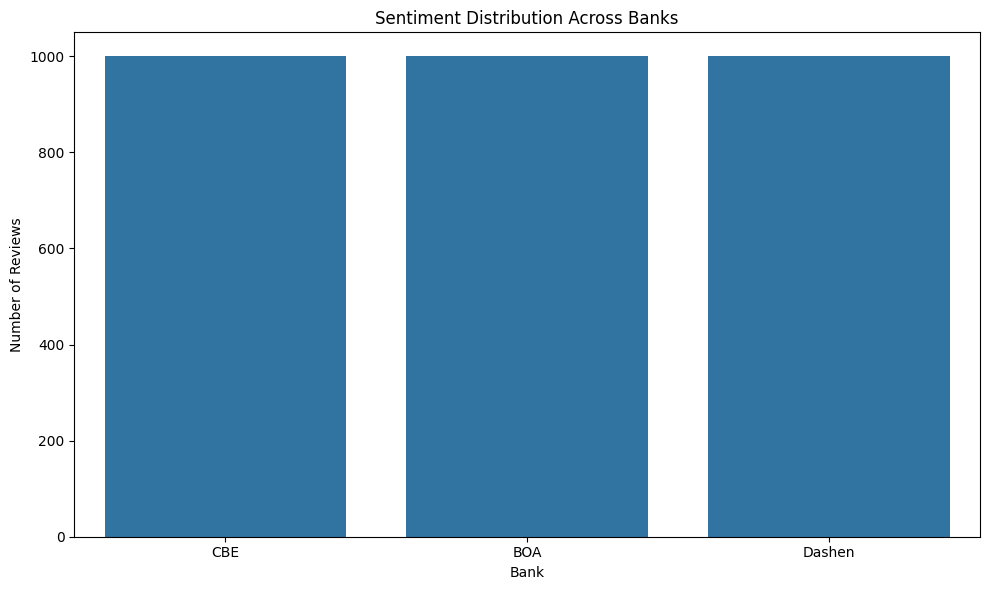

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="bank_name"
)

plt.title("Sentiment Distribution Across Banks")

plt.xlabel("Bank")

plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [31]:
ratings_query = """
SELECT
    b.bank_name,
    ROUND(AVG(r.rating), 2) AS average_rating
FROM reviews r
JOIN banks b
ON r.bank_id = b.bank_id
GROUP BY b.bank_name;
"""

ratings_df = pd.read_sql(
    ratings_query,
    engine
)

ratings_df

,bank_name,average_rating
0,BOA,3.23
1,CBE,4.07
2,Dashen,4.16


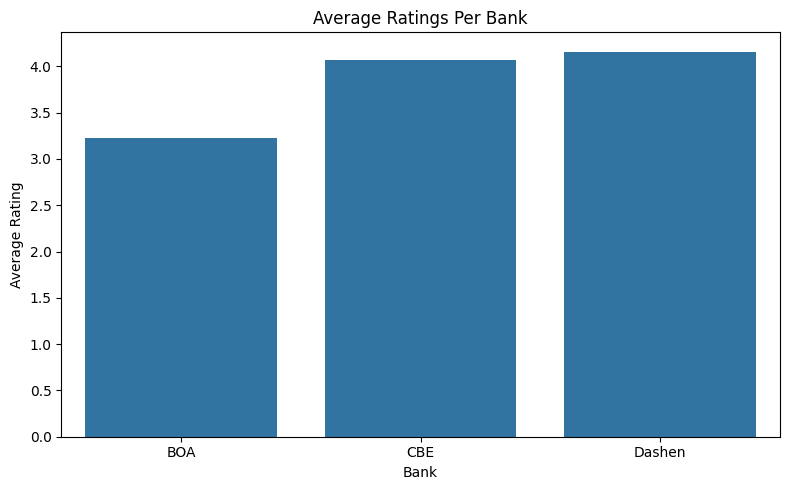

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=ratings_df,
    x="bank_name",
    y="average_rating"
)

plt.title("Average Ratings Per Bank")

plt.xlabel("Bank")

plt.ylabel("Average Rating")

plt.tight_layout()

plt.show()

In [34]:
volume_query = """
SELECT
    b.bank_name,
    COUNT(r.review_id) AS total_reviews
FROM reviews r
JOIN banks b
ON r.bank_id = b.bank_id
GROUP BY b.bank_name;
"""

volume_df = pd.read_sql(
    volume_query,
    engine
)

volume_df

,bank_name,total_reviews
0,BOA,1000
1,CBE,1000
2,Dashen,1000


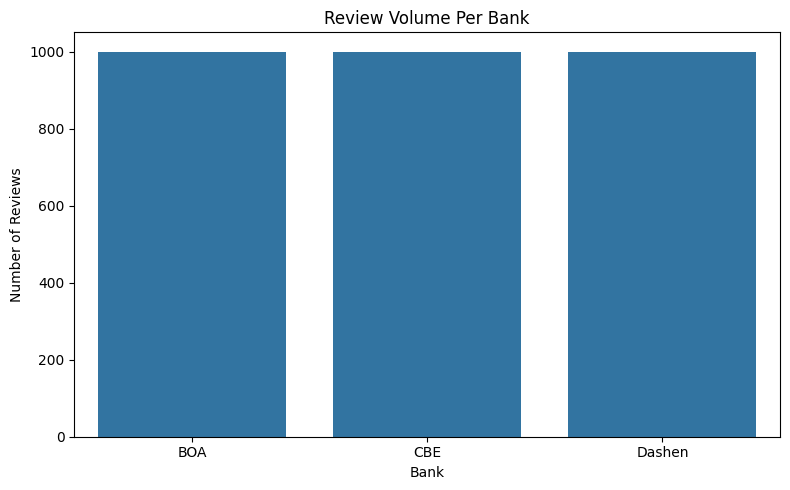

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=volume_df,
    x="bank_name",
    y="total_reviews"
)

plt.title("Review Volume Per Bank")

plt.xlabel("Bank")

plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

In [42]:
from sqlalchemy import text

with engine.connect() as conn:
    print(conn.execute(text("SELECT current_database();")).fetchone())

('fintech_reviews_db',)


In [52]:
theme_query = """
SELECT
    sentiment_label,
    COUNT(*) AS total_mentions
FROM sentiments
GROUP BY sentiment_label
ORDER BY total_mentions DESC;
"""

themes_df = pd.read_sql(
    theme_query,
    engine
)

themes_df.head(10)

,sentiment_label,total_mentions
0,positive,1834
1,neutral,803
2,negative,363


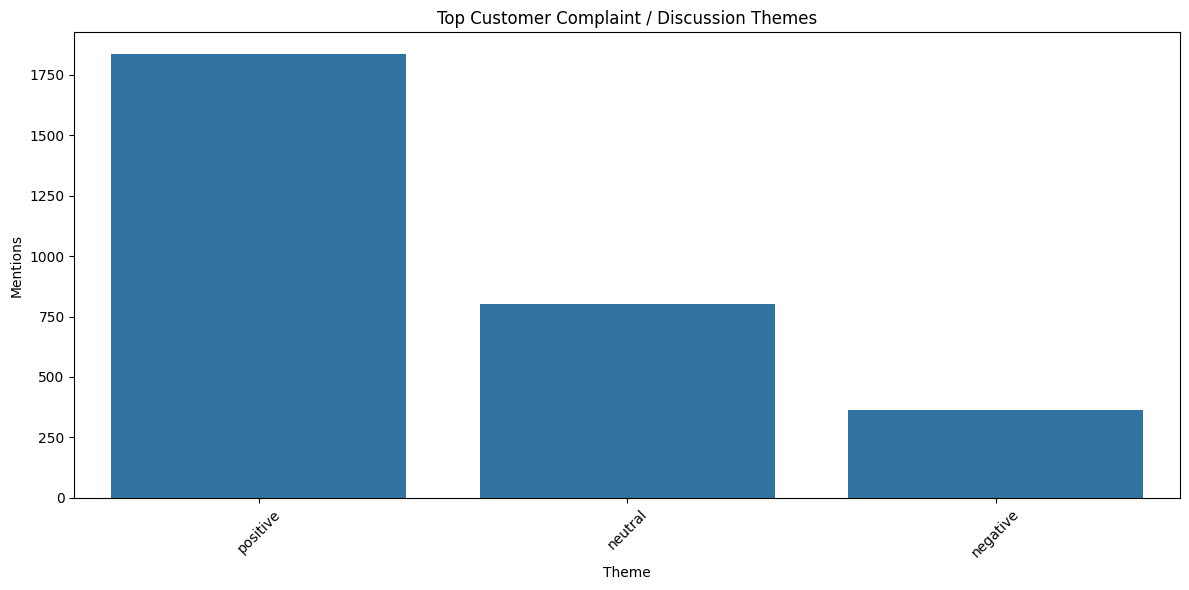

In [53]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=themes_df.head(10),
    x="sentiment_label",
    y="total_mentions"
)

plt.title("Top Customer Complaint / Discussion Themes")

plt.xlabel("Theme")

plt.ylabel("Mentions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

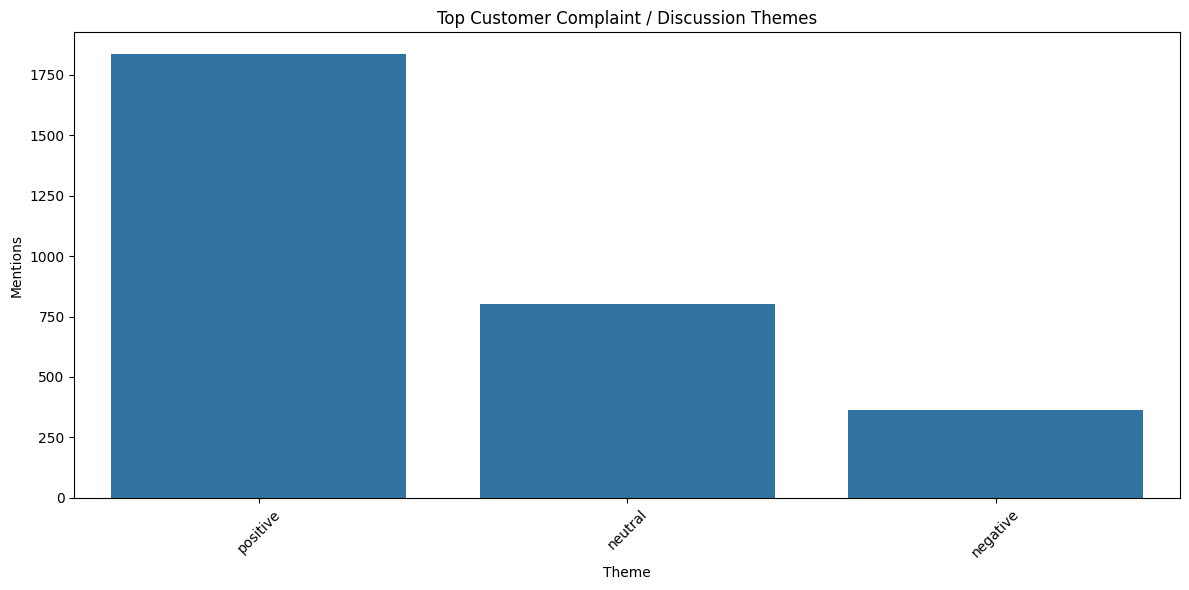

In [55]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=themes_df.head(10),
    x="sentiment_label",
    y="total_mentions"
)

plt.title("Top Customer Complaint / Discussion Themes")

plt.xlabel("Theme")

plt.ylabel("Mentions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

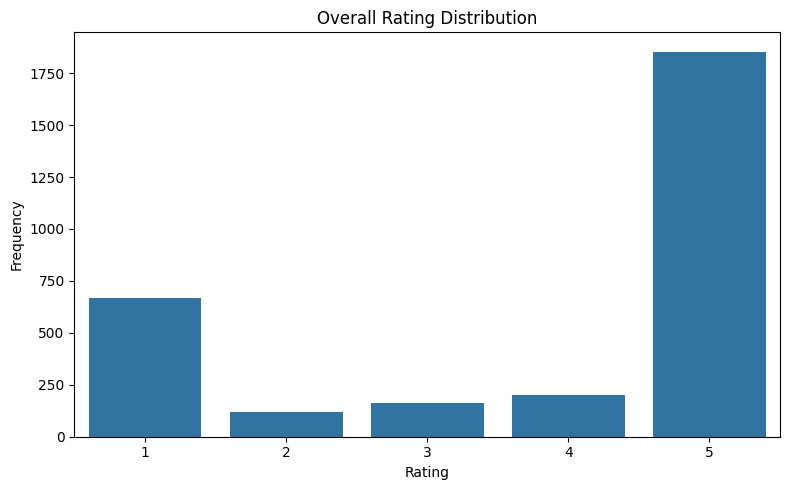

In [57]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="rating"
)

plt.title("Overall Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

## Key Analytical Insights

### Customer Satisfaction
Banks with higher average ratings generally demonstrate better perceived application stability and usability.

### Common Negative Themes
Recurring complaints include:
- login failures,
- OTP verification problems,
- application crashes,
- and delayed transaction processing.

### Positive Feedback Drivers
Positive reviews frequently mention:
- convenience,
- fast transfers,
- improved UI,
- and accessibility.

### Business Impact
The analysis demonstrates that customer experience issues directly influence app ratings and public perception of fintech services.

# Business Recommendations

### Commercial Bank of Ethiopia (CBE)
- Improve server reliability during peak traffic periods.
- Optimize login and authentication workflows.
- Improve responsiveness of transaction confirmation systems.

### Bank of Abyssinia (BOA)
- Enhance UI consistency and navigation simplicity.
- Improve app stability across Android versions.
- Expand customer support responsiveness.

### Dashen Bank
- Address recurring OTP and verification complaints.
- Improve transaction processing reliability.
- Enhance onboarding experience for new users.

### Cross-Bank Strategic Recommendations
- Introduce proactive customer issue monitoring.
- Implement crash analytics and automated error reporting.
- Increase responsiveness to Play Store complaints.
- Improve release testing before production deployment.

# Conclusion

This notebook successfully integrated:
- PostgreSQL analytical querying,
- NLP sentiment analysis,
- thematic exploration,
- and business intelligence visualization.

The analysis identified key drivers of customer satisfaction and operational dissatisfaction across Ethiopian fintech banking applications.

The findings provide actionable recommendations that can support product improvement, customer retention, and fintech service optimization.